# Exploratory Data Analysis
Exploring HAM10000 dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load Metadata

In [2]:
df = pd.read_csv('../archive/HAM10000_metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## Check Missing Values & Info

In [3]:
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB
None

Missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


Fill missing age values with median.

In [4]:
df['age'] = df['age'].fillna(df['age'].median())

## Class Imbalance

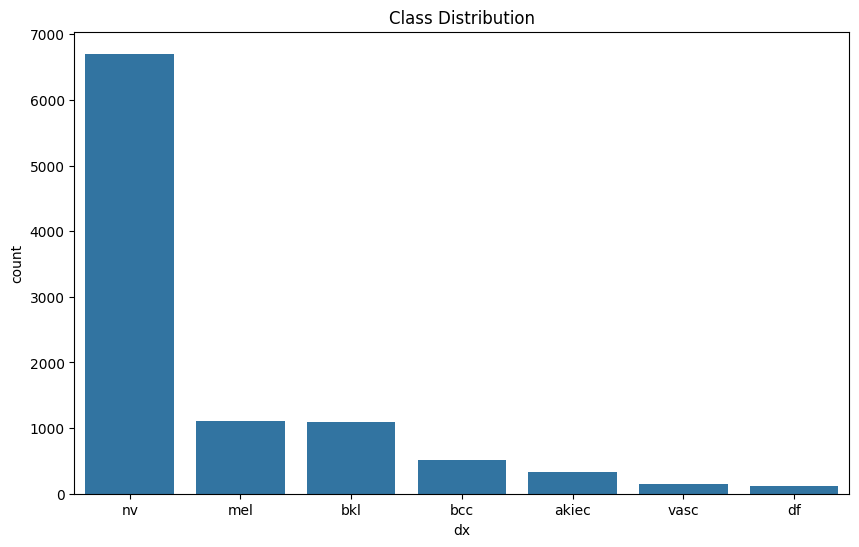

In [5]:
plt.figure(figsize=(10,6))
sns.countplot(x='dx', data=df, order=df['dx'].value_counts().index)
plt.title('Class Distribution')
plt.show()

We observe massive class imbalance. `nv` is the majority class.

## Age, Sex and Localization

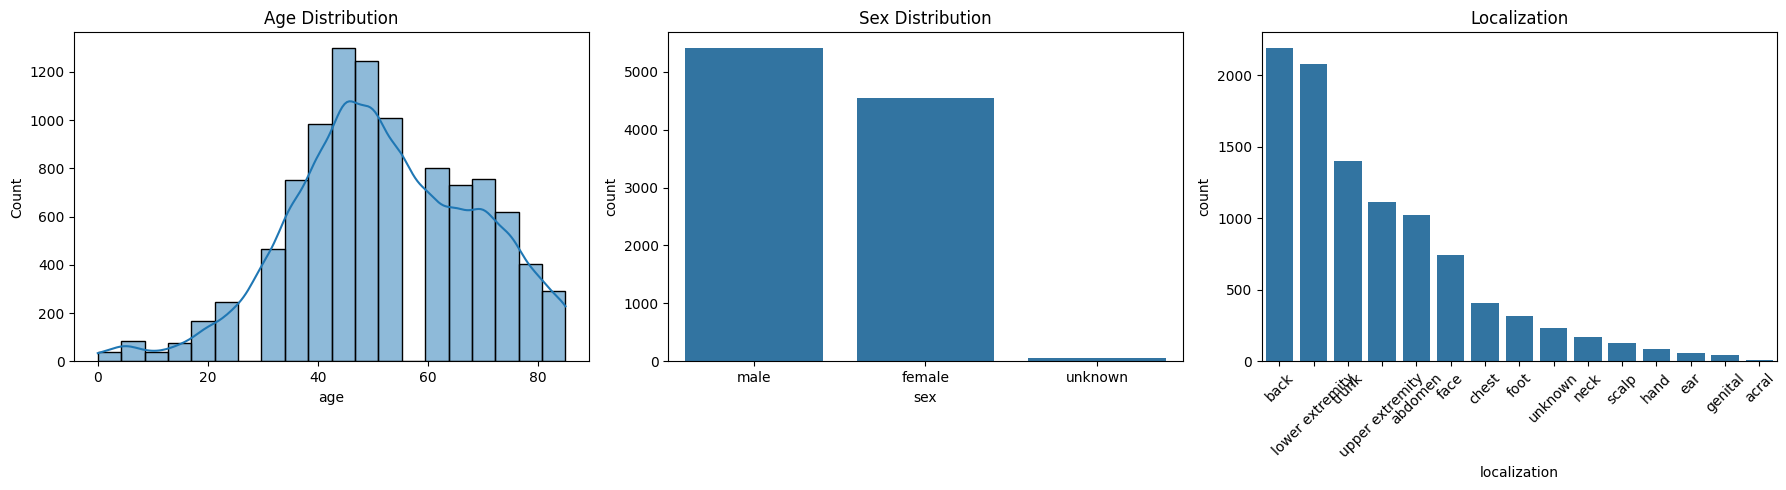

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.countplot(x='sex', data=df, ax=axes[1])
axes[1].set_title('Sex Distribution')

sns.countplot(x='localization', data=df, order=df['localization'].value_counts().index, ax=axes[2])
axes[2].set_title('Localization')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()